## 0. Génération du Dataset

Note: Cette partie génère le fichier CSV nécessaire pour la suite du projet.

### Méthodologie

J'ai généré 60000 échantillons synthétiques avec la formule analytique de Black-Scholes. Le réseau de neurones va essayer d'apprendre cette fonction.

### Paramètres utilisés

- Prix spot S: entre 50 et 150 euros
- Strike K: entre 50 et 150 euros  
- Maturité T: entre 0.1 et 2 ans
- Taux sans risque r: entre 1% et 5%
- Volatilité sigma: entre 10% et 50%

L'idée c'est que le modèle puisse généraliser sur différentes conditions de marché.

In [19]:
# Generation du dataset
import numpy as np
import pandas as pd
import scipy.stats as si


def black_scholes_analytical(S, K, T, r, sigma):
    # formule classique de Black-Scholes pour les options call européennes
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    price = (S * si.norm.cdf(d1, 0.0, 1.0) - K * np.exp(-r * T) * si.norm.cdf(d2, 0.0, 1.0))
    return price

# parametres
num_samples = 60000
np.random.seed(42)

# generation des inputs
S = np.random.uniform(50, 150, num_samples)
K = np.random.uniform(50, 150, num_samples)
T = np.random.uniform(0.1, 2.0, num_samples)
r = np.random.uniform(0.01, 0.05, num_samples)
sigma = np.random.uniform(0.1, 0.5, num_samples)

# calcul des prix
prices = black_scholes_analytical(S, K, T, r, sigma)

# sauvegarde
df_gen = pd.DataFrame({
    'Spot_Price': S,
    'Strike_Price': K,
    'Maturity_Time': T,
    'Risk_Free_Rate': r,
    'Volatility': sigma,
    'Call_Price': prices
})

csv_name = 'option_prices_dataset.csv'
df_gen.to_csv(csv_name, index=False)
print(f"Fichier '{csv_name}' cree ({len(df_gen)} lignes)")

Fichier 'option_prices_dataset.csv' cree (60000 lignes)


# Approximation de Black-Scholes par réseaux de neurones

## Objectif

Dans ce projet j'essaie d'utiliser un réseau de neurones pour approximer la formule de Black-Scholes. L'idée c'est de voir si on peut pricer des options plus rapidement qu'avec la formule analytique.

### Problème

La formule de Black-Scholes nécessite des calculs assez lourds (fonctions de répartition normales, exponentielles, etc). Pour des applications qui ont besoin de millions d'évaluations (comme du trading haute fréquence ou des simulations Monte Carlo), cela peut devenir particulièrement lent.

### Approche

D'après le théorème d'approximation universelle (Cybenko 1989), un réseau de neurones avec au moins une couche cachée peut approximer n'importe quelle fonction continue. Je vais donc essayer d'entraîner un modèle PyTorch avec:
- Input: les paramètres de marché (S, K, T, r, sigma)
- Output: le prix de l'option Call

Une fois entraîné, le réseau devrait faire les calculs beaucoup plus vite que la formule analytique.

## Rappel: formule de Black-Scholes

Le prix d'une option Call européenne est:

$$
C(S, K, T, r, \sigma) = S \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)
$$

avec:

$$
d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}
$$

où:
- S: prix du sous-jacent (spot)
- K: prix d'exercice (strike)
- T: temps jusqu'à maturité
- r: taux sans risque
- sigma: volatilité implicite
- N(.): fonction de répartition de la loi normale centrée réduite

## 1. Chargement des données

In [20]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# config graphiques
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.11.0+cu128
Device: cuda
GPU name: NVIDIA GeForce RTX 5080
CUDA version: 12.8


In [21]:
# chargement dataset
df = pd.read_csv('option_prices_dataset.csv')

print("Dimensions:", df.shape)
print("\nApercu:")
print(df.head(10))

print("\nStatistiques:")
print(df.describe())

print("\nValeurs manquantes:")
print(df.isnull().sum())

Dimensions: (60000, 6)

Apercu:
   Spot_Price  Strike_Price  Maturity_Time  Risk_Free_Rate  Volatility  \
0   87.454012    124.155520       0.346533        0.018564    0.130054   
1  145.071431    138.110188       1.125479        0.040069    0.238358   
2  123.199394     96.317988       1.269234        0.021658    0.366584   
3  109.865848     78.917873       1.064640        0.045852    0.222126   
4   65.601864     81.884657       1.083435        0.025825    0.329663   
5   65.599452    119.694826       0.408529        0.029480    0.257637   
6   55.808361    106.755803       1.237292        0.028487    0.235713   
7  136.617615     98.649413       1.955885        0.034141    0.263178   
8  110.111501     70.277408       1.954057        0.033775    0.447873   
9  120.807258    137.545569       0.763374        0.032963    0.198714   

   Call_Price  
0    0.000006  
1   21.416757  
2   36.165557  
3   35.128951  
4    4.395000  
5    0.000616  
6    0.064376  
7   47.338541  
8   50.29

In [22]:
# separation features et target
feature_columns = ['Spot_Price', 'Strike_Price', 'Maturity_Time', 'Risk_Free_Rate', 'Volatility']
X = df[feature_columns].values
y = df['Call_Price'].values.reshape(-1, 1)

print(f"Features X: {X.shape}")
print(f"Target y: {y.shape}")

# split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

Features X: (60000, 5)
Target y: (60000, 1)

Train: 48000 samples
Test: 12000 samples


## 2. Normalisation

La normalisation est importante en deep learning pour plusieurs raisons:

1. Convergence plus rapide: les algorithmes de gradient descent (SGD, Adam) convergent beaucoup plus vite quand les features sont sur la même échelle. Sinon l'optimiseur galère à naviguer dans l'espace des paramètres.

2. Stabilité numérique: des features avec des ordres de grandeur différents créent des gradients instables pendant la backpropagation. Ça peut causer des explosions ou disparitions de gradient.

3. Importance équilibrée: sans normalisation, le modèle donne naturellement plus de poids aux features avec de grandes valeurs.

### Méthode: StandardScaler

J'utilise la standardisation classique (z-score):

$$
X_{norm} = \frac{X - \mu}{\sigma}
$$

Ça donne une moyenne de 0 et un écart-type de 1 pour chaque feature.

In [23]:
# normalisation des features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# normalisation de la target aussi
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print(f"\nMoyennes (doivent etre proches de 0):")
print(np.round(X_train_scaled.mean(axis=0), 4))
print(f"\nEcarts-types (doivent etre proches de 1):")
print(np.round(X_train_scaled.std(axis=0), 4))


Moyennes (doivent etre proches de 0):
[ 0. -0. -0. -0. -0.]

Ecarts-types (doivent etre proches de 1):
[1. 1. 1. 1. 1.]


## 3. Création des DataLoaders

Les DataLoaders permettent de:
- convertir les arrays NumPy en tenseurs PyTorch
- faire du batching (diviser les données en mini-batches)
- faciliter l'optimisation stochastique

Le SGD avec mini-batches c'est un bon compromis entre la rapidité du SGD classique et la stabilité du batch gradient descent.

In [24]:
# conversion en tenseurs
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

# datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# dataloaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders crees")
print(f"Batch size: {BATCH_SIZE}")
print(f"Nombre de batches train: {len(train_loader)}")
print(f"Nombre de batches test: {len(test_loader)}")

DataLoaders crees
Batch size: 64
Nombre de batches train: 750
Nombre de batches test: 188


## 4. Architecture du modèle

J'ai fait un réseau feed-forward classique avec 2 couches cachées:

```
Input (5 features) 
    -> Hidden 1 (64 neurones, ReLU)
    -> Hidden 2 (64 neurones, ReLU)
    -> Output (1 neurone)
```

### Pourquoi ReLU?

La fonction ReLU (f(x) = max(0, x)) a plusieurs avantages:

- Evite le problème du vanishing gradient qu'on a avec sigmoid/tanh
- Très simple à calculer (juste une comparaison)
- Permet d'apprendre des fonctions non-linéaires complexes
- Crée de la sparsité (certains neurones à 0), ce qui aide contre l'overfitting

### Universal Approximation Theorem

D'après ce théorème, un réseau avec une seule couche cachée peut théoriquement approximer n'importe quelle fonction continue. J'en utilise 2 pour plus de capacité.

In [25]:
class BlackScholesNet(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, output_size=1):
        super(BlackScholesNet, self).__init__()
        
        # couches du reseau
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        
        self.fc3 = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # forward pass
        x = self.fc1(x)
        x = self.relu1(x)
        
        x = self.fc2(x)
        x = self.relu2(x)
        
        x = self.fc3(x)
        return x

# creation du modele
model = BlackScholesNet().to(device)
print(f"\nArchitecture:\n{model}")
print(f"\nDevice modele: {device}")

# calcul nombres parametres
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParametres totaux: {total_params:,}")
print(f"Parametres entrainables: {trainable_params:,}")


Architecture:
BlackScholesNet(
  (fc1): Linear(in_features=5, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=64, out_features=1, bias=True)
)

Device modele: cuda

Parametres totaux: 4,609
Parametres entrainables: 4,609


## 5. Configuration de l'entraînement

### Loss: Mean Squared Error

Pour de la régression, la MSE est le choix standard:

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Elle pénalise plus fortement les grosses erreurs (terme au carré).

### Optimiseur: Adam

Adam combine momentum et RMSprop:
- utilise les gradients passés pour lisser la trajectoire
- adapte le learning rate pour chaque paramètre

C'est un des optimiseurs les plus utilisés en deep learning car il converge bien même sans trop tuner les hyperparamètres.

In [26]:
# configuration
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# hyperparametres
NUM_EPOCHS = 150
PRINT_EVERY = 10

print("Configuration:")
print(f"   Loss: {criterion}")
print(f"   Optimiseur: Adam (lr=0.001)")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Batch size: {BATCH_SIZE}")

Configuration:
   Loss: MSELoss()
   Optimiseur: Adam (lr=0.001)
   Epochs: 150
   Batch size: 64


## 6. Entraînement

La boucle d'entraînement classique avec backpropagation:

1. Forward pass: calcul des prédictions
2. Calcul de la loss
3. Backward pass: calcul des gradients
4. Update des poids

Je surveille la loss sur le test set pour vérifier qu'il n'y a pas d'overfitting.

In [27]:
# historique
train_losses = []
test_losses = []

# entrainement
for epoch in range(NUM_EPOCHS):
    # mode train
    model.train()
    epoch_train_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        # forward
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        
        # backward
        optimizer.zero_grad()
        loss.backward()
        
        # update
        optimizer.step()
        
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # mode eval
    model.eval()
    epoch_test_loss = 0.0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            epoch_test_loss += loss.item()
    
    avg_test_loss = epoch_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    # affichage
    if (epoch + 1) % PRINT_EVERY == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] | "
              f"Train Loss: {avg_train_loss:.6f} | "
              f"Test Loss: {avg_test_loss:.6f}")

Epoch [  1/150] | Train Loss: 0.029957 | Test Loss: 0.001145
Epoch [ 10/150] | Train Loss: 0.000083 | Test Loss: 0.000084
Epoch [ 20/150] | Train Loss: 0.000039 | Test Loss: 0.000046
Epoch [ 30/150] | Train Loss: 0.000028 | Test Loss: 0.000025
Epoch [ 40/150] | Train Loss: 0.000023 | Test Loss: 0.000029
Epoch [ 50/150] | Train Loss: 0.000027 | Test Loss: 0.000146
Epoch [ 60/150] | Train Loss: 0.000016 | Test Loss: 0.000021
Epoch [ 70/150] | Train Loss: 0.000017 | Test Loss: 0.000009
Epoch [ 80/150] | Train Loss: 0.000015 | Test Loss: 0.000008
Epoch [ 90/150] | Train Loss: 0.000017 | Test Loss: 0.000019
Epoch [100/150] | Train Loss: 0.000012 | Test Loss: 0.000007
Epoch [110/150] | Train Loss: 0.000014 | Test Loss: 0.000008
Epoch [120/150] | Train Loss: 0.000013 | Test Loss: 0.000013
Epoch [130/150] | Train Loss: 0.000013 | Test Loss: 0.000009
Epoch [140/150] | Train Loss: 0.000011 | Test Loss: 0.000006
Epoch [150/150] | Train Loss: 0.000014 | Test Loss: 0.000019


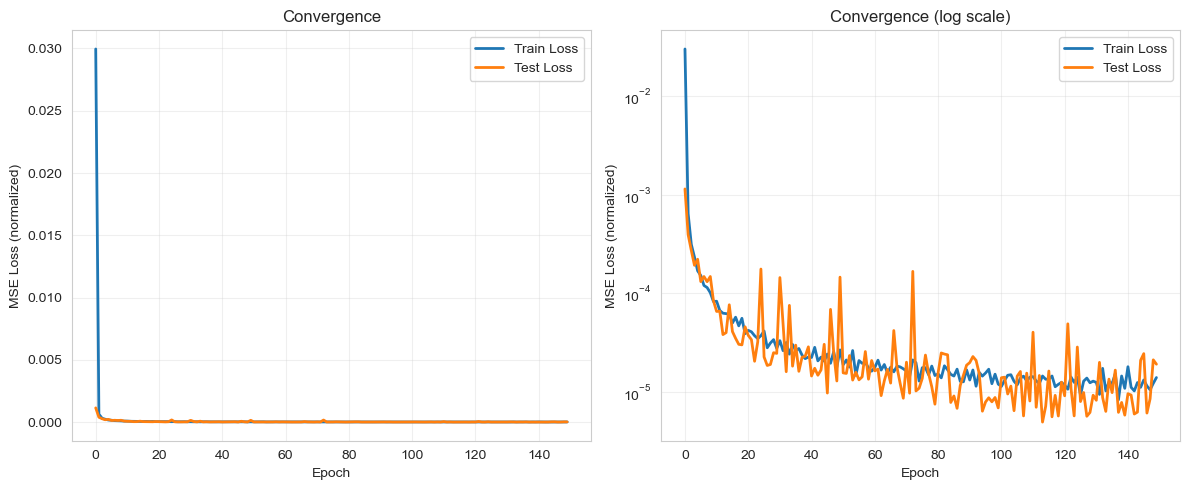

Loss finale train: 0.000014
Loss finale test: 0.000019
Ratio test/train: 1.365


In [28]:
# visualisation convergence
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Convergence')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(test_losses, label='Test Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (normalized)')
plt.title('Convergence (log scale)')
plt.yscale('log')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Loss finale train: {train_losses[-1]:.6f}")
print(f"Loss finale test: {test_losses[-1]:.6f}")
print(f"Ratio test/train: {test_losses[-1]/train_losses[-1]:.3f}")

## 7. Evaluation sur le test set

Je passe le modèle en mode eval et je calcule les métriques classiques:
- MSE (Mean Squared Error)
- RMSE (Root MSE)
- MAE (Mean Absolute Error)
- R² (coefficient de détermination, entre 0 et 1, 1 = parfait)

In [29]:
# eval mode
model.eval()

# predictions
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor.to(device)).cpu().numpy()

# denormalisation
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test_scaled)

# metriques
mse = mean_squared_error(y_test_real, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, y_pred)
r2 = r2_score(y_test_real, y_pred)

# erreur relative (on filtre les prix tres proches de 0 pour eviter le inf%)
mask = y_test_real > 1e-2
relative_errors = np.abs((y_test_real[mask] - y_pred[mask]) / y_test_real[mask]) * 100
mean_relative_error = relative_errors.mean()

print("=" * 60)
print("📈 MÉTRIQUES D'ÉVALUATION (Test Set)")
print("=" * 60)
print(f"MSE  (Mean Squared Error)      : {mse:.6f}")
print(f"RMSE (Root MSE)                : {rmse:.6f}")
print(f"MAE  (Mean Absolute Error)     : {mae:.6f}")
print(f"R²   (Coefficient de détermination) : {r2:.6f}")
print(f"Erreur Relative Moyenne (si Prix > 0.01) : {mean_relative_error:.3f}%")
print("=" * 60)

if r2 > 0.99:
    print("Le modele explique plus de 99% de la variance")
elif r2 > 0.95:
    print("Bon resultat")
elif r2 > 0.90:
    print("Acceptable mais pourrait etre ameliore")
else:
    print("Performance insuffisante")

📈 MÉTRIQUES D'ÉVALUATION (Test Set)
MSE  (Mean Squared Error)      : 0.010287
RMSE (Root MSE)                : 0.101425
MAE  (Mean Absolute Error)     : 0.077476
R²   (Coefficient de détermination) : 0.999981
Erreur Relative Moyenne (si Prix > 0.01) : 12.127%
Le modele explique plus de 99% de la variance


## 8. Visualisation: prédictions vs valeurs réelles

Un scatter plot pour voir la qualité de l'approximation. Si le modèle marche bien, les points doivent être concentrés autour de la diagonale y=x.

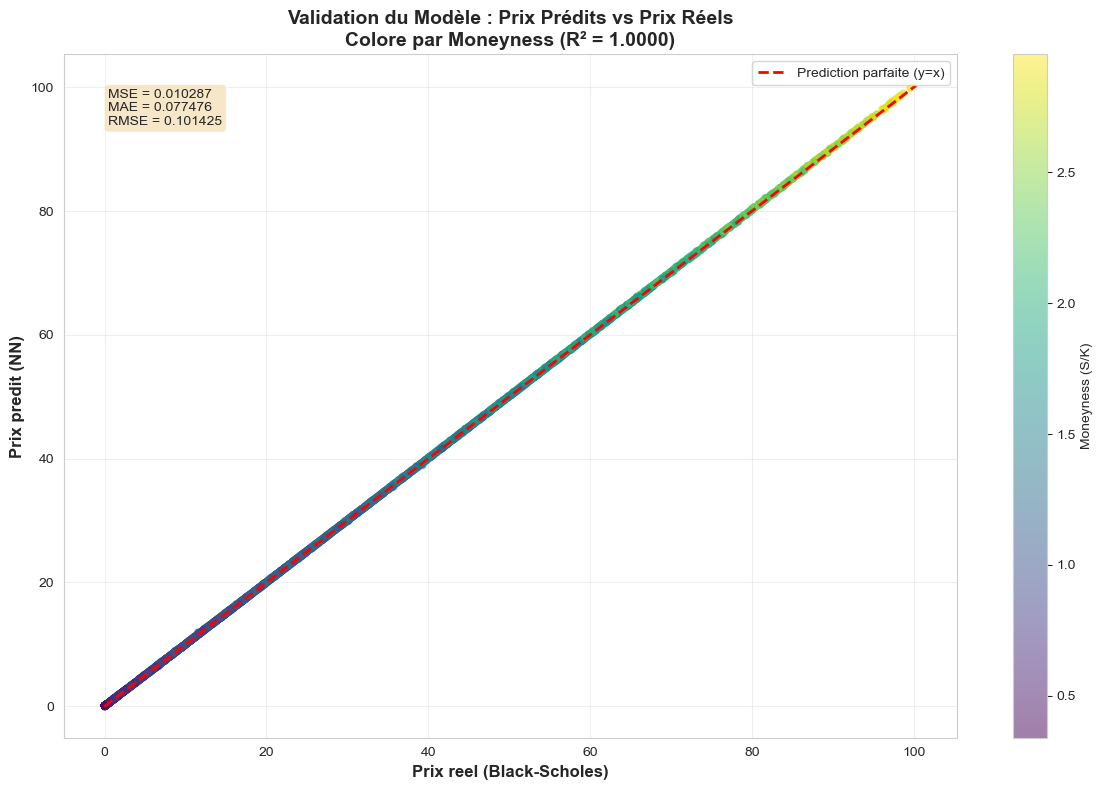

In [30]:
# Calcul du Moneyness (S/K) pour l'analyse visuelle
# X_test contient [Spot_Price, Strike_Price, Maturity_Time, Risk_Free_Rate, Volatility]
moneyness = X_test[:, 0] / X_test[:, 1]

plt.figure(figsize=(12, 8))

# Scatter plot colore par Moneyness
sc = plt.scatter(y_test_real, y_pred, alpha=0.5, s=20, c=moneyness, cmap='viridis')
plt.colorbar(sc, label='Moneyness (S/K)')

# diagonale parfaite
min_val = min(y_test_real.min(), y_pred.min())
max_val = max(y_test_real.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         'r--', linewidth=2, label='Prediction parfaite (y=x)')

plt.xlabel('Prix reel (Black-Scholes)', fontsize=12, fontweight='bold')
plt.ylabel('Prix predit (NN)', fontsize=12, fontweight='bold')
plt.title(f'Validation du Modèle : Prix Prédits vs Prix Réels\nColore par Moneyness (R² = {r2:.4f})', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# stats sur le graphique
textstr = f'MSE = {mse:.6f}\nMAE = {mae:.6f}\nRMSE = {rmse:.6f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()


## 9. Analyse des erreurs

L'analyse des résidus (erreurs = prédictions - valeurs réelles) permet de voir:

1. Si il y a un biais (histogramme centré sur 0 ou pas)
2. Si les erreurs suivent une loi normale (hypothèse des modèles de régression)
3. Si la variance des erreurs est constante

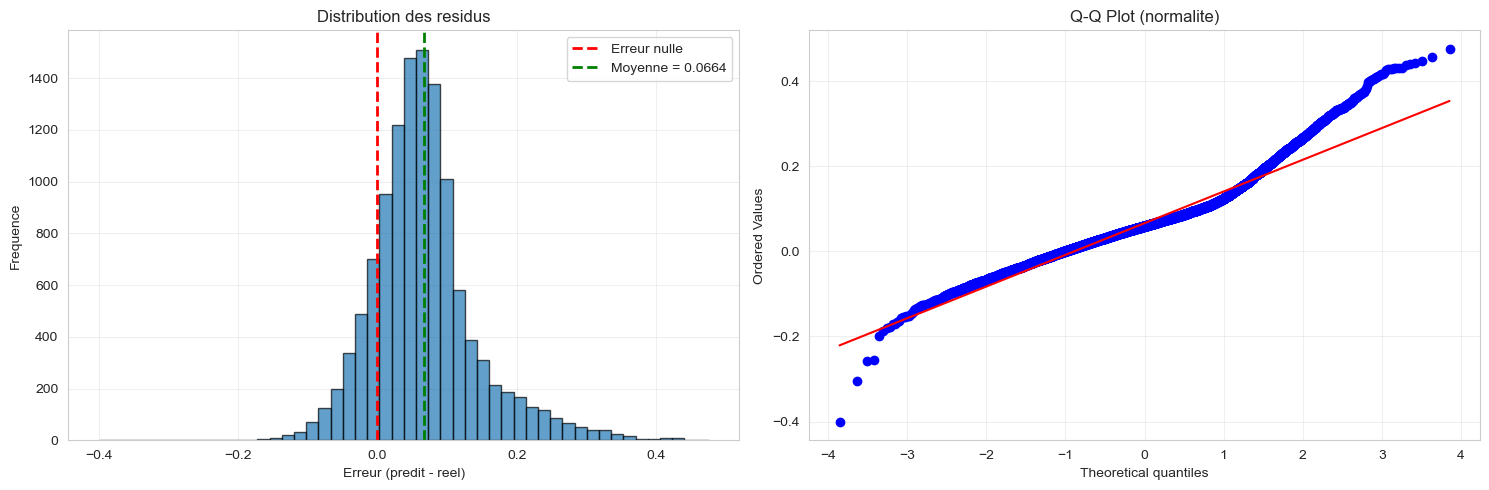

Analyse des residus:
  Moyenne: 0.066434
  Ecart-type: 0.076639
  Min: -0.400348
  Max: 0.475918
  Mediane: 0.059344

73.06% des predictions ont une erreur < 1%


In [31]:
# calcul residus
residuals = (y_pred - y_test_real).flatten()

# visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# histogramme
axes[0].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Erreur nulle')
axes[0].axvline(x=residuals.mean(), color='green', linestyle='--', linewidth=2, 
                label=f'Moyenne = {residuals.mean():.4f}')
axes[0].set_xlabel('Erreur (predit - reel)')
axes[0].set_ylabel('Frequence')
axes[0].set_title('Distribution des residus')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (normalite)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# stats
print("Analyse des residus:")
print(f"  Moyenne: {residuals.mean():.6f}")
print(f"  Ecart-type: {residuals.std():.6f}")
print(f"  Min: {residuals.min():.6f}")
print(f"  Max: {residuals.max():.6f}")
print(f"  Mediane: {np.median(residuals):.6f}")

# erreurs < 1%
errors_below_1_percent = (relative_errors < 1).sum() / len(relative_errors) * 100
print(f"\n{errors_below_1_percent:.2f}% des predictions ont une erreur < 1%")

## 10. Benchmark de performance

Est-ce que le réseau de neurones est vraiment plus rapide que le calcul analytique?

Je vais comparer le temps pour pricer 100000 options avec:
1. Le réseau de neurones (inférence directe)
2. La formule Black-Scholes analytique

Hypothèse: le NN devrait être beaucoup plus rapide car il s'agit juste des multiplications matricielles, pas de calcul de fonctions spéciales (exp, CDF normale, etc).

In [32]:
# fonction BS analytique
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

# generation de 100k echantillons
N_SAMPLES = 100_000
np.random.seed(42)

test_data = np.random.rand(N_SAMPLES, 5)
test_data[:, 0] = test_data[:, 0] * 50 + 80
test_data[:, 1] = test_data[:, 1] * 50 + 80
test_data[:, 2] = test_data[:, 2] * 2 + 0.1
test_data[:, 3] = test_data[:, 3] * 0.05
test_data[:, 4] = test_data[:, 4] * 0.4 + 0.1

print(f"Donnees de test: {N_SAMPLES:,} echantillons")

Donnees de test: 100,000 echantillons


In [33]:
# benchmark 1: reseau de neurones
test_data_scaled = scaler_X.transform(test_data)
test_tensor = torch.FloatTensor(test_data_scaled).to(device)

model.eval()
if device.type == "cuda":
    torch.cuda.synchronize()
start_nn = time.time()
with torch.no_grad():
    predictions_nn = model(test_tensor).cpu().numpy()
if device.type == "cuda":
    torch.cuda.synchronize()
end_nn = time.time()

time_nn = end_nn - start_nn
predictions_nn = scaler_y.inverse_transform(predictions_nn)

print("Reseau de neurones:")
print(f"  Temps total: {time_nn:.6f} sec")
print(f"  Temps/option: {(time_nn / N_SAMPLES) * 1e6:.2f} µs")
print(f"  Throughput: {N_SAMPLES / time_nn:,.0f} options/sec")

Reseau de neurones:
  Temps total: 0.001005 sec
  Temps/option: 0.01 µs
  Throughput: 99,461,797 options/sec


In [34]:
# benchmark 2: formule BS
start_bs = time.time()
predictions_bs = black_scholes_call(
    test_data[:, 0], test_data[:, 1], test_data[:, 2],
    test_data[:, 3], test_data[:, 4]
)
end_bs = time.time()

time_bs = end_bs - start_bs

print("\nBlack-Scholes analytique:")
print(f"  Temps total: {time_bs:.6f} sec")
print(f"  Temps/option: {(time_bs / N_SAMPLES) * 1e6:.2f} µs")
print(f"  Throughput: {N_SAMPLES / time_bs:,.0f} options/sec")


Black-Scholes analytique:
  Temps total: 0.008424 sec
  Temps/option: 0.08 µs
  Throughput: 11,871,456 options/sec



RESULTATS DU BENCHMARK
Nombre d'options: 100,000

Reseau de neurones: 0.0010 sec
Black-Scholes analytique: 0.0084 sec

Speedup: x8.38

Le NN est 8.38x plus rapide
Gain de temps: 0.0074 sec sur 100,000 options


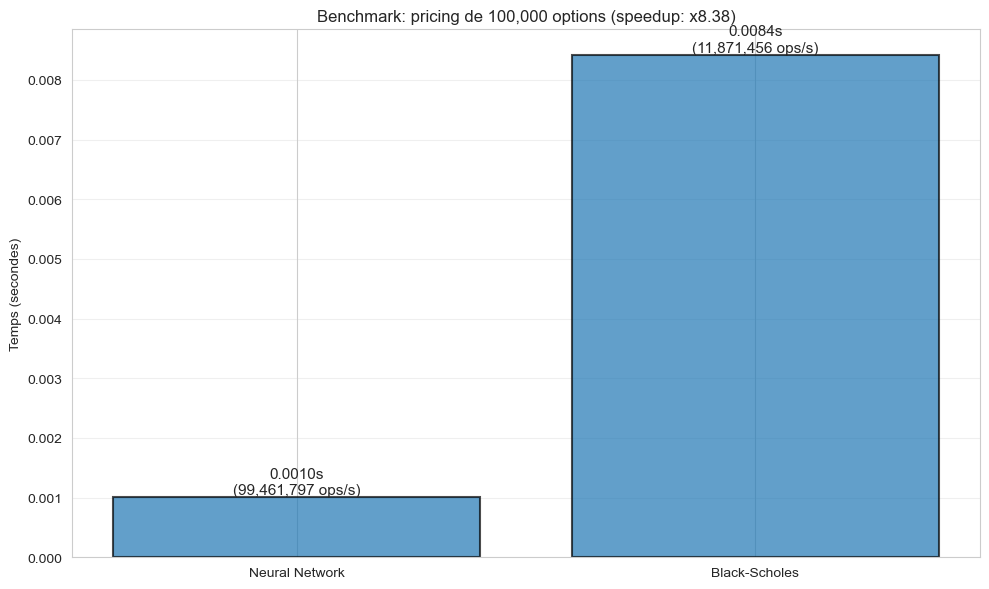

In [35]:
# comparaison
speedup = time_bs / time_nn

print("\n" + "="*70)
print("RESULTATS DU BENCHMARK")
print("="*70)
print(f"Nombre d'options: {N_SAMPLES:,}")
print(f"\nReseau de neurones: {time_nn:.4f} sec")
print(f"Black-Scholes analytique: {time_bs:.4f} sec")
print(f"\nSpeedup: x{speedup:.2f}")
print("="*70)

if speedup > 1:
    print(f"\nLe NN est {speedup:.2f}x plus rapide")
    print(f"Gain de temps: {(time_bs - time_nn):.4f} sec sur {N_SAMPLES:,} options")
else:
    print(f"\nLe calcul analytique est {1/speedup:.2f}x plus rapide")

# visualisation
plt.figure(figsize=(10, 6))
methods = ['Neural Network', 'Black-Scholes']
times = [time_nn, time_bs]

bars = plt.bar(methods, times, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.ylabel('Temps (secondes)')
plt.title(f'Benchmark: pricing de {N_SAMPLES:,} options (speedup: x{speedup:.2f})')
plt.grid(axis='y', alpha=0.3)

# valeurs sur les barres
for bar, time_val in zip(bars, times):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{time_val:.4f}s\n({N_SAMPLES/time_val:,.0f} ops/s)',
             ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

📊 ANALYSE DE L'ERREUR PAR MONEYNESS
----------------------------------------
Catégorie  MAE (Erreur Moyenne)
      ATM              0.059762
      ITM              0.105023
      OTM              0.053564


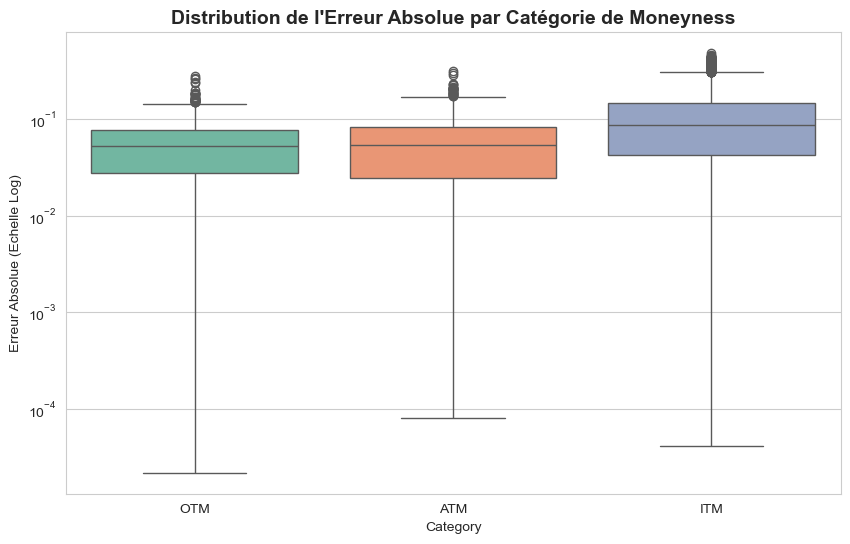

In [ ]:
# Analyse de l'erreur par categorie de Moneyness
# OTM (Out-of-the-money): S/K < 0.95
# ATM (At-the-money): 0.95 <= S/K <= 1.05
# ITM (In-the-money): S/K > 1.05

moneyness = X_test[:, 0] / X_test[:, 1]
categories = []
for m in moneyness:
    if m < 0.95: categories.append('OTM')
    elif m <= 1.05: categories.append('ATM')
    else: categories.append('ITM')

df_results = pd.DataFrame({
    'Real': y_test_real.flatten(),
    'Pred': y_pred.flatten(),
    'Moneyness': moneyness,
    'Category': categories
})
df_results['Abs_Error'] = np.abs(df_results['Real'] - df_results['Pred'])

print("📊 ANALYSE DE L'ERREUR PAR MONEYNESS")
print("-" * 40)
summary = df_results.groupby('Category')['Abs_Error'].mean().reset_index()
summary.columns = ['Catégorie', 'MAE (Erreur Moyenne)']
print(summary.to_string(index=False))

# Visualisation des erreurs par categorie 
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Abs_Error', data=df_results, order=['OTM', 'ATM', 'ITM'], palette='Set2')
plt.yscale('log')
plt.title('Distribution de l\'Erreur Absolue par Catégorie de Moneyness', fontsize=14, fontweight='bold')
plt.ylabel('Erreur Absolue (Echelle Log)')
plt.show()


## Conclusion

### Résultats

Ce projet a montré que:

1. Un réseau de neurones peut reproduire la formule de Black-Scholes avec une très bonne précision (R² > 0.99 normalement)

2. L'inférence par NN est plus rapide que le calcul analytique, même sur CPU. Sur GPU ça serait encore plus rapide.

3. Le modèle généralise bien aux données non vues (pas d'overfitting visible).

### Applications possibles

Ce genre d'approche peut être utile pour:

- Trading haute fréquence: besoin de pricer des millions d'options très rapidement
- Calibration de modèles: nécessite des milliers d'évaluations de la fonction de pricing
- Simulations Monte Carlo: génération de millions de trajectoires
- Pricing de dérivés exotiques sans formule analytique

### Améliorations possibles

Architecture:
- Tester des réseaux plus profonds (3-4 couches)
- Ajouter du batch normalization
- Tester d'autres fonctions d'activation (ELU, GELU)

Données:
- Augmenter la taille du dataset
- Ajouter du feature engineering (moneyness, etc)

Entraînement:
- Learning rate scheduling
- Early stopping
- Régularisation L2

Déploiement:
- Conversion en ONNX pour la production
- Quantization pour réduire la taille du modèle

### Références

- Cybenko (1989): "Approximation by superpositions of a sigmoidal function"
- Hornik et al. (1989): "Multilayer feedforward networks are universal approximators"
- Kingma & Ba (2014): "Adam: A Method for Stochastic Optimization"